# Pipeline and ColumnTransformer in Machine Learning

## Table of Contents
1. Introduction to Pipelines
2. Basic Pipeline Example
3. Pipeline with Feature Engineering
4. Introduction to ColumnTransformer
5. ColumnTransformer with Different Transformations
6. Combining Pipeline and ColumnTransformer
7. Advanced Example: Complete ML Workflow
8. GridSearchCV with Pipeline
9. Saving and Loading Pipelines

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris, fetch_california_housing
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Introduction to Pipelines

A Pipeline in scikit-learn is a way to chain multiple transformers and estimators into a single object. It helps in:
- **Streamlining** the preprocessing and modeling process
- **Avoiding data leakage** by applying transformations consistently
- **Simplifying** cross-validation and hyperparameter tuning
- **Making code cleaner** and more maintainable

In [2]:
# Load Iris dataset
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target

print("Iris Dataset Shape:", X_iris.shape)
print("\nFirst 5 rows:")
X_iris.head()

Iris Dataset Shape: (150, 4)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# pd.DataFrame(iris.data)

In [4]:
# iris

## 2. Basic Pipeline Example

Let's create a simple pipeline that scales the data and then applies a classifier.

In [5]:
# Create a basic pipeline
basic_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scale features
    ('classifier', LogisticRegression(max_iter=1000))  # Step 2: Apply classifier
])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

# Train the pipeline
basic_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = basic_pipeline.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [18]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [6]:
X_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
73,6.1,2.8,4.7,1.2
18,5.7,3.8,1.7,0.3
118,7.7,2.6,6.9,2.3
78,6.0,2.9,4.5,1.5
76,6.8,2.8,4.8,1.4
31,5.4,3.4,1.5,0.4
64,5.6,2.9,3.6,1.3
141,6.9,3.1,5.1,2.3
68,6.2,2.2,4.5,1.5
82,5.8,2.7,3.9,1.2


In [7]:
X_test.shape


(45, 4)

In [8]:
import pickle

In [9]:
import pickle

# Load the saved model from disk
with open("iris.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)

# Use the loaded model to make a prediction
sample_data = [[4.6, 3.1, 1.5, 0.2]]
prediction = loaded_pipeline.predict(sample_data)

print("Predicted Class:", prediction[0])

Predicted Class: 0


In [10]:
with open("iris.pkl", "wb") as f:
    pickle.dump(basic_pipeline,f)
    print("Pipeline loaded successfully!")

Pipeline loaded successfully!


In [11]:
with open("iris.pkl", "rb") as f:
    model = pickle.load(f)
    predicted=model.predict([[4.6,	3.1,	1.5,	0.2]])

In [12]:
print(predicted[0])

0


In [20]:
print(predicted[0])

1


In [19]:
with open("iris.pkl", "rb") as f:
    model = pickle.load(f)
    predicted=model.predict([[6.7,	3.1,	4.7,	1.5]])
  

## 3. Pipeline with Feature Engineering

Pipelines can include custom feature engineering steps.

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA

# Pipeline with feature engineering
feature_engineering_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
    ('pca', PCA(n_components=2)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train and evaluate
feature_engineering_pipeline.fit(X_train, y_train)
y_pred_fe = feature_engineering_pipeline.predict(X_test)

print("Accuracy with Feature Engineering:", accuracy_score(y_test, y_pred_fe))
print("\nPipeline Steps:")
for step_name, step in feature_engineering_pipeline.named_steps.items():
    print(f"  {step_name}: {step.__class__.__name__}")

Accuracy with Feature Engineering: 0.8888888888888888

Pipeline Steps:
  scaler: StandardScaler
  polynomial: PolynomialFeatures
  pca: PCA
  classifier: RandomForestClassifier


## 4. Introduction to ColumnTransformer

ColumnTransformer is used to apply different transformations to different columns of your dataset. This is particularly useful when dealing with mixed data types (numerical and categorical).

In [14]:
# Create a dataset with mixed data types
np.random.seed(42)
n_samples = 1000

# Create synthetic data
data = {
    'age': np.random.randint(18, 70, n_samples),
    'income': np.random.normal(50000, 15000, n_samples),
    'gender': np.random.choice(['Male', 'Female'], n_samples),
    'education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_samples),
    'city': np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston'], n_samples),
    'score': np.random.normal(70, 15, n_samples)
}

df = pd.DataFrame(data)

# Add some missing values
df.loc[np.random.choice(df.index, 50, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 30, replace=False), 'age'] = np.nan

# Create target variable
df['target'] = (df['score'] > 70).astype(int)

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1000, 7)

Data types:
age          float64
income       float64
gender           str
education        str
city             str
score        float64
target         int64
dtype: object

Missing values:
age          30
income       50
gender        0
education     0
city          0
score         0
target        0
dtype: int64

First 5 rows:


,age,income,gender,education,city,score,target
0,56.0,25903.305196,Male,High School,Chicago,69.410391,0
1,69.0,53051.954538,Female,Bachelor,Houston,67.982548,0
2,46.0,NaN,Female,PhD,Houston,75.007899,1
3,32.0,28666.194356,Male,PhD,Houston,91.470502,1
4,60.0,40301.406736,Male,Master,Los Angeles,86.226501,1


In [15]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['age', 'income', 'score']
Categorical columns: ['gender', 'education', 'city']


## 5. ColumnTransformer with Different Transformations

Let's create a ColumnTransformer that applies different transformations to numerical and categorical columns.

In [16]:
# Create transformers for numerical and categorical columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Apply the preprocessor
X_transformed = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_transformed.shape)
print("\nFeature names from one-hot encoding:")
print(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols))

Original shape: (1000, 6)
Transformed shape: (1000, 13)

Feature names from one-hot encoding:
['gender_Female' 'gender_Male' 'education_Bachelor'
 'education_High School' 'education_Master' 'education_PhD' 'city_Chicago'
 'city_Houston' 'city_Los Angeles' 'city_New York']


## 6. Combining Pipeline and ColumnTransformer

The real power comes when we combine both Pipeline and ColumnTransformer.

In [21]:
# Create the full pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(f_classif, k='all')),  # We'll use all features for now
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the pipeline
full_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = full_pipeline.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Get feature importance (for logistic regression)
if hasattr(full_pipeline.named_steps['classifier'], 'coef_'):
    # Get feature names after transformation
    feature_names = full_pipeline.named_steps['preprocessor'].get_feature_names_out()
    coefficients = full_pipeline.named_steps['classifier'].coef_[0]
    
    # Create feature importance DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    }).sort_values('abs_coefficient', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10))

Accuracy: 0.9933333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       156
           1       1.00      0.99      0.99       144

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300


Top 10 Most Important Features:
                       feature  coefficient  abs_coefficient
2                   num__score     7.708420         7.708420
6   cat__education_High School    -0.279541         0.279541
7        cat__education_Master     0.198888         0.198888
10           cat__city_Houston    -0.177493         0.177493
9            cat__city_Chicago     0.141996         0.141996
11       cat__city_Los Angeles     0.129080         0.129080
3           cat__gender_Female     0.114424         0.114424
0                     num__age     0.111448         0.111448
5      cat__education_Bachelor     0.1

## 7. Advanced Example: Complete ML Workflow

Let's create a more comprehensive workflow with:
- Advanced preprocessing
- Feature engineering
- Feature selection
- Multiple models

In [22]:
# Create advanced preprocessor
advanced_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True))
])

advanced_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

advanced_preprocessor = ColumnTransformer(
    transformers=[
        ('num', advanced_numeric_transformer, numerical_cols),
        ('cat', advanced_categorical_transformer, categorical_cols)
    ])

# Create pipelines for different models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', advanced_preprocessor),
        ('feature_selector', SelectKBest(f_classif, k=10)),  # Select top 10 features
        ('classifier', model)
    ])
    
    # Cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    
    # Train on full training set
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    results[model_name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': accuracy
    }
    
    print(f"\n{model_name} Results:")
    print(f"  CV Score: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    print(f"  Test Accuracy: {accuracy:.3f}")


Logistic Regression Results:
  CV Score: 0.993 (+/- 0.006)
  Test Accuracy: 0.997

Random Forest Results:
  CV Score: 0.999 (+/- 0.003)
  Test Accuracy: 0.997


In [ ]:
# Compare models
results_df = pd.DataFrame(results).T
results_df

## 8. GridSearchCV with Pipeline

One of the biggest advantages of pipelines is the ability to perform hyperparameter tuning with GridSearchCV or RandomizedSearchCV.

In [23]:
# Create a pipeline with placeholders for hyperparameters
pipeline_for_tuning = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5, 10]
}

# Perform GridSearchCV
grid_search = GridSearchCV(
    pipeline_for_tuning,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV Score: {grid_search.best_score_:.3f}")
print(f"Test Score with Best Model: {grid_search.score(X_test, y_test):.3f}")

Starting GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Parameters:
  classifier__max_depth: 5
  classifier__min_samples_split: 2
  classifier__n_estimators: 50

Best CV Score: 1.000
Test Score with Best Model: 0.997


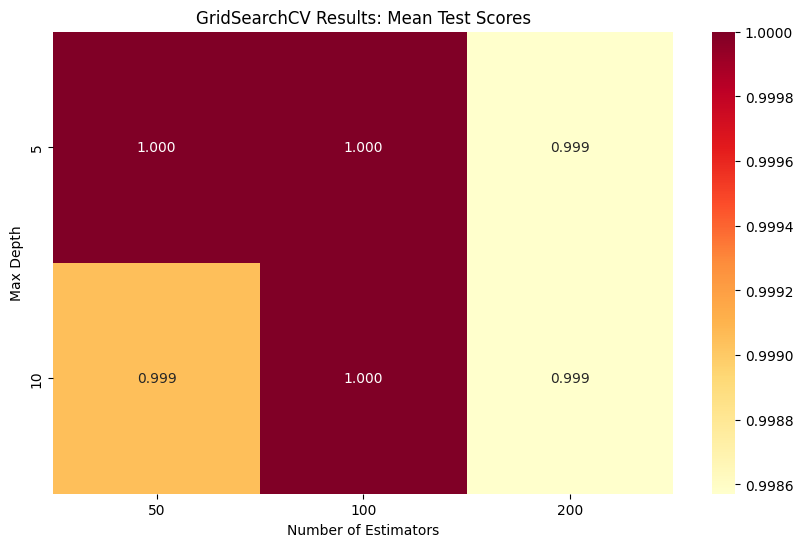

In [24]:
# Visualize GridSearch results
results_grid = pd.DataFrame(grid_search.cv_results_)

# Create a heatmap of results
pivot_table = results_grid.pivot_table(
    values='mean_test_score',
    index='param_classifier__max_depth',
    columns='param_classifier__n_estimators'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('GridSearchCV Results: Mean Test Scores')
plt.xlabel('Number of Estimators')
plt.ylabel('Max Depth')
plt.show()

## 9. Saving and Loading Pipelines

Pipelines can be saved and loaded for later use.

In [ ]:
import joblib
import os

# Create a directory for models if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the best model from GridSearch
joblib.dump(grid_search.best_estimator_, 'models/best_pipeline.pkl')

print("Model saved successfully!")

# Load the model
loaded_pipeline = joblib.load('models/best_pipeline.pkl')

# Use the loaded model for predictions
y_pred_loaded = loaded_pipeline.predict(X_test)
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)

print(f"\nAccuracy from loaded model: {accuracy_loaded:.3f}")

# Verify that predictions match
print(f"Predictions match original: {np.array_equal(y_pred_loaded, y_pred)}")

## Summary

### Key Takeaways:

1. **Pipelines** help organize preprocessing and modeling steps into a single object
2. **ColumnTransformer** applies different transformations to different column types
3. **Together**, they create flexible and maintainable ML workflows
4. **Benefits:**
   - Prevent data leakage
   - Code reusability
   - Easy hyperparameter tuning
   - Consistent preprocessing
   - Cleaner code

### Best Practices:
1. Always use pipelines for production-ready code
2. Use ColumnTransformer for mixed data types
3. Perform hyperparameter tuning within pipelines
4. Save and load pipelines for deployment
5. Use cross-validation within pipelines

### Common Pitfalls to Avoid:
1. Don't apply transformations on the full dataset before splitting
2. Make sure to handle missing values appropriately
3. Don't forget to include all necessary preprocessing steps
4. Be careful with feature names when using ColumnTransformer

In [ ]:
# Clean up saved files
import shutil

if os.path.exists('models'):
    shutil.rmtree('models')
    print("Cleanup completed!")